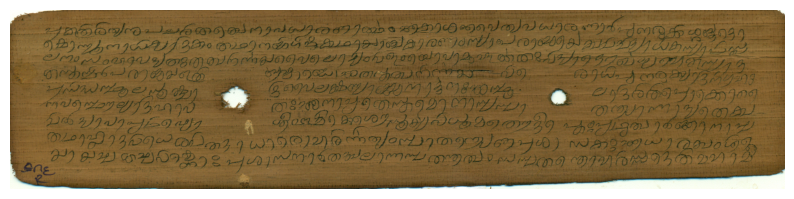

In [83]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import pywt


# Load the image
image_path = 'NAGRAJA BHAT SMVITM-20250202T164531Z-001/NAGRAJA BHAT SMVITM/TP43_S1030/P-216-R.tif'
image = Image.open(image_path)

# Display the image in a large scale
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')  # Hide the axis
plt.show()

In [72]:
image_np = np.array(image)

In [73]:
# 2. Convert the RGB image to grayscale
# (If your image is in RGB, use COLOR_RGB2GRAY; if in BGR, use COLOR_BGR2GRAY)
gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

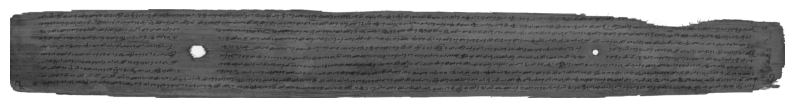

In [74]:
plt.figure(figsize=(10, 10))
plt.imshow(gray, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

In [75]:
def apply_wavelet_transform(image):
    """Applies Discrete Wavelet Transform (DWT) to an image."""
    coeffs2 = pywt.dwt2(image, 'haar')
    LL, (LH, HL, HH) = coeffs2  # Decomposing into subbands
    
    # Reconstruct the image using approximation coefficients (LL)
    reconstructed = pywt.idwt2((LL, (None, None, None)), 'haar')
    reconstructed = np.uint8(reconstructed)

    return reconstructed

gray_welwet = apply_wavelet_transform(gray)

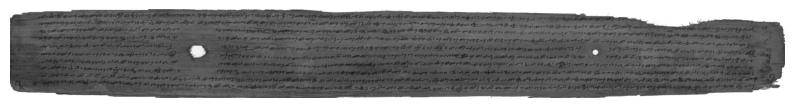

In [76]:
plt.figure(figsize=(10, 10))
plt.imshow(gray_welwet, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

In [77]:
# 3. Denoise the grayscale image using fastNlMeansDenoising.
#    Parameters: h (filter strength), templateWindowSize, searchWindowSize.
denoised = cv2.fastNlMeansDenoising(gray, None, h=19, templateWindowSize=4, searchWindowSize=21)

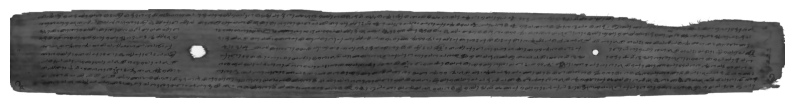

In [78]:
plt.figure(figsize=(10, 10))
plt.imshow(denoised, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

In [79]:
# 4. Apply adaptive thresholding (binarization).
#    - Max value: 255
#    - Adaptive method: GAUSSIAN_C (accounts for local variations)
#    - Threshold type: THRESH_BINARY
#    - Block size: 11 (size of the neighborhood)
#    - Constant C: 2 (subtracted from the mean)
binary = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                               cv2.THRESH_BINARY, 11, 2)

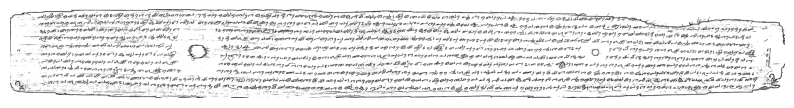

In [80]:
plt.figure(figsize=(10, 10))
plt.imshow(binary, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

In [81]:
# 5. (Optional) Enhance the binary image with morphological operations.
#    Here we use dilation to help connect broken parts of the text.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
morphed = cv2.dilate(binary, kernel, iterations=1)

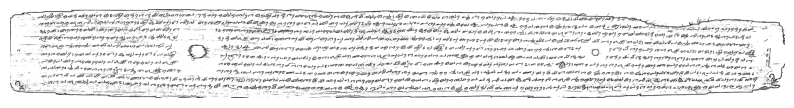

In [82]:
plt.figure(figsize=(10, 10))
plt.imshow(morphed, cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

Detected Line Indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72 114 115 116 117 212 213 214 215 216 217 344 345 346 347 348 371 380
 381 382 383 384 385 437 474 475 476 477 478 479 480 481 482 487 489 490
 491 492 501 506 507 508 509 510 511 512 513 514 515 516 517 518 519 520
 521 522 523 541 542 543 544 545 546 547 548 549 550 551 552 553 567 568
 569 570 571 572 573]


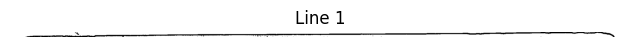

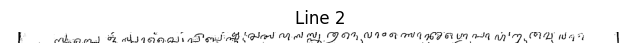

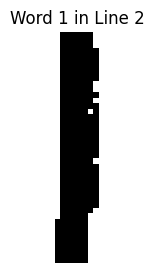

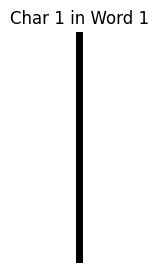

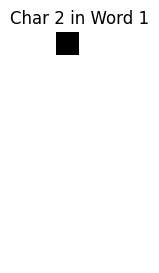

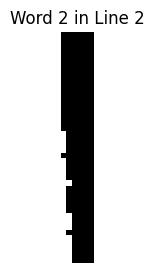

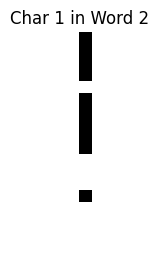

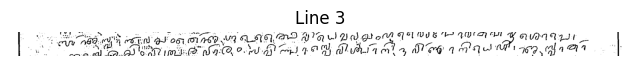

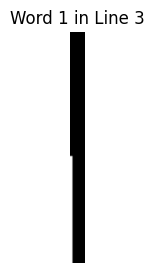

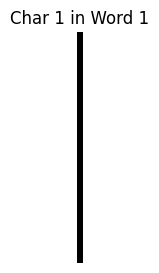

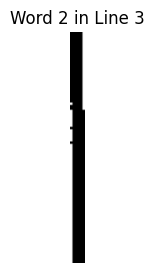

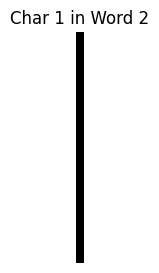

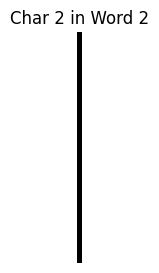

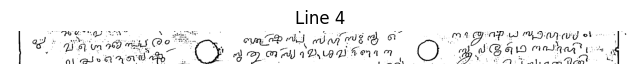

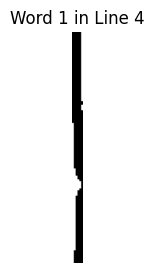

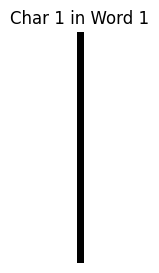

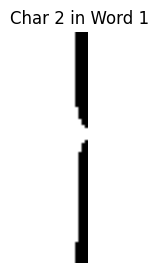

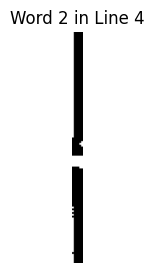

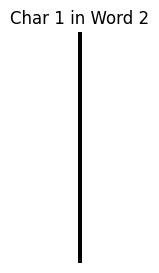

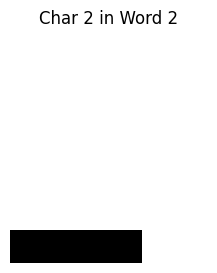

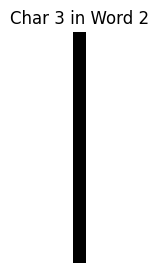

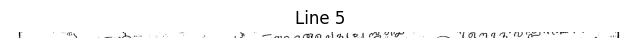

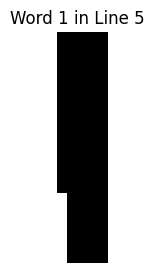

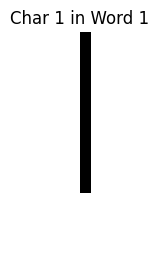

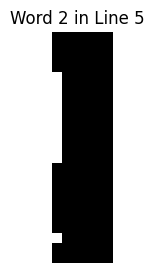

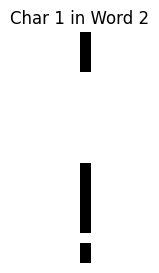

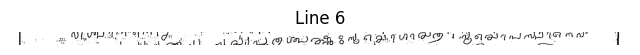

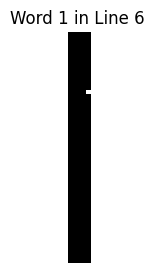

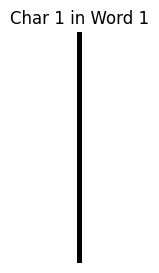

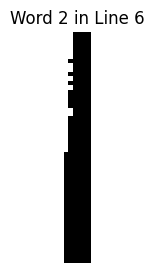

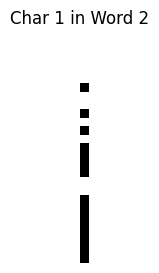

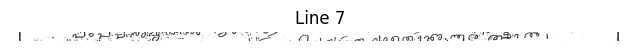

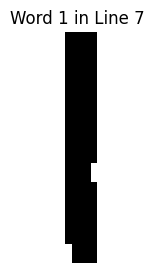

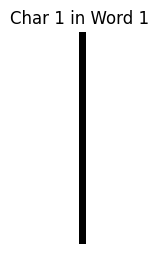

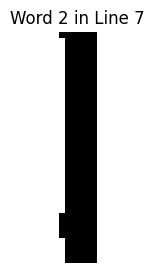

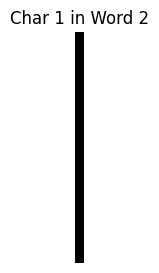

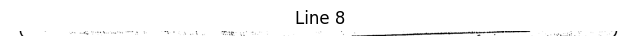

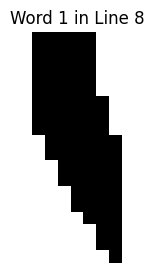

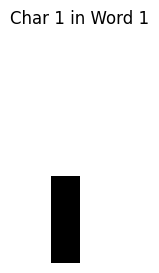

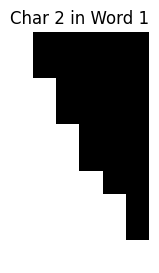

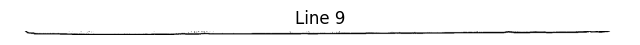

Total Lines Detected: 9
Line 1: 0 Words Detected
Line 2: 2 Words Detected
Word 1 in Line 2: 2 Characters Detected
Word 2 in Line 2: 1 Characters Detected
Line 3: 2 Words Detected
Word 1 in Line 3: 1 Characters Detected
Word 2 in Line 3: 2 Characters Detected
Line 4: 2 Words Detected
Word 1 in Line 4: 2 Characters Detected
Word 2 in Line 4: 3 Characters Detected
Line 5: 2 Words Detected
Word 1 in Line 5: 1 Characters Detected
Word 2 in Line 5: 1 Characters Detected
Line 6: 2 Words Detected
Word 1 in Line 6: 1 Characters Detected
Word 2 in Line 6: 1 Characters Detected
Line 7: 2 Words Detected
Word 1 in Line 7: 1 Characters Detected
Word 2 in Line 7: 1 Characters Detected
Line 8: 1 Words Detected
Word 1 in Line 8: 2 Characters Detected
Line 9: 0 Words Detected


In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def segment_lines(image):
    """Performs line segmentation using Horizontal Projection Profile."""
    hist = np.sum(image, axis=1)
    threshold = np.mean(hist) *1.03
    line_indices = np.where(hist > threshold)[0]

    print("Detected Line Indices:", line_indices)  # Debugging
    if len(line_indices) == 0:
        print("No lines detected!")

    segmented_lines = []
    prev_index = line_indices[0] if len(line_indices) > 0 else 0

    for i in range(1, len(line_indices)):
        if line_indices[i] - prev_index > 10:
            segmented_lines.append(image[prev_index:line_indices[i], :])
        prev_index = line_indices[i]

    return segmented_lines


def segment_words(line_image):
    """Performs word segmentation using Vertical Projection Profile & Morphology."""
    hist = np.sum(line_image, axis=0)

    # Detect gaps between words
    threshold = np.mean(hist) * 0.5
    word_indices = np.where(hist > threshold)[0]

    segmented_words = []
    prev_index = word_indices[0]

    for i in range(1, len(word_indices)):
        if word_indices[i] - prev_index > 5:  # Minimum gap threshold
            segmented_words.append(line_image[:, prev_index:word_indices[i]])
        prev_index = word_indices[i]

    return segmented_words

def segment_characters(word_image):
    """Performs character segmentation using Connected Component Analysis (CCA)."""
    # Find connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(word_image, connectivity=8)

    segmented_chars = []
    for i in range(1, num_labels):  # Ignore the background
        x, y, w, h, area = stats[i]
        if area > 10:  # Filter small components
            char = word_image[y:y+h, x:x+w]
            segmented_chars.append(char)

    return segmented_chars

# Load the binary image
binary_image = morphed

# Perform line segmentation
lines = segment_lines(binary_image)

# Display segmented lines
for i, line in enumerate(lines):
    plt.figure(figsize=(8, 3))
    plt.imshow(line, cmap='gray')
    plt.title(f'Line {i+1}')
    plt.axis("off")
    plt.show()

    # Perform word segmentation on each line
    words = segment_words(line)
    for j, word in enumerate(words):
        plt.figure(figsize=(6, 3))
        plt.imshow(word, cmap='gray')
        plt.title(f'Word {j+1} in Line {i+1}')
        plt.axis("off")
        plt.show()

        # Perform character segmentation on each word
        chars = segment_characters(word)
        for k, char in enumerate(chars):
            plt.figure(figsize=(3, 3))
            plt.imshow(char, cmap='gray')
            plt.title(f'Char {k+1} in Word {j+1}')
            plt.axis("off")
            plt.show()
print(f"Total Lines Detected: {len(lines)}")
for i, line in enumerate(lines):
    words = segment_words(line)
    print(f"Line {i+1}: {len(words)} Words Detected")

    for j, word in enumerate(words):
        chars = segment_characters(word)
        print(f"Word {j+1} in Line {i+1}: {len(chars)} Characters Detected")

